In [4]:
# ICA

In [5]:
# Step 1: Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

In [6]:
# Step 2: Generate or define source signals

# Suggested idea for this batch:
# - sinusoidal signal
# - square-like signal using sign(sin(.))
# - sawtooth-like ramp signal or random noise signal

# TODO:
# np.random.seed(...)
# n_samples = ...
# time = np.linspace(0, 8, n_samples)
# s1 = np.sin(2 * time)
# s2 = np.sign(np.sin(3 * time))
# s3 = 2 * ((time / np.pi) % 1) - 1      # simple ramp-like signal
# S = np.c_[s1, s2, s3]
# S = S / S.std(axis=0)
# print(S.shape)
#------------------------------------------------------------

np.random.seed(0)
n_samples = 1000
time = np.linspace(0, 8, n_samples)
s1 = np.sin(2 * time)                  
s2 = np.sign(np.sin(3 * time))            
s3 = 2 * ((time / np.pi) % 1) - 1         
S = np.c_[s1, s2, s3]
S = S / S.std(axis=0)
print(S.shape)


(1000, 3)


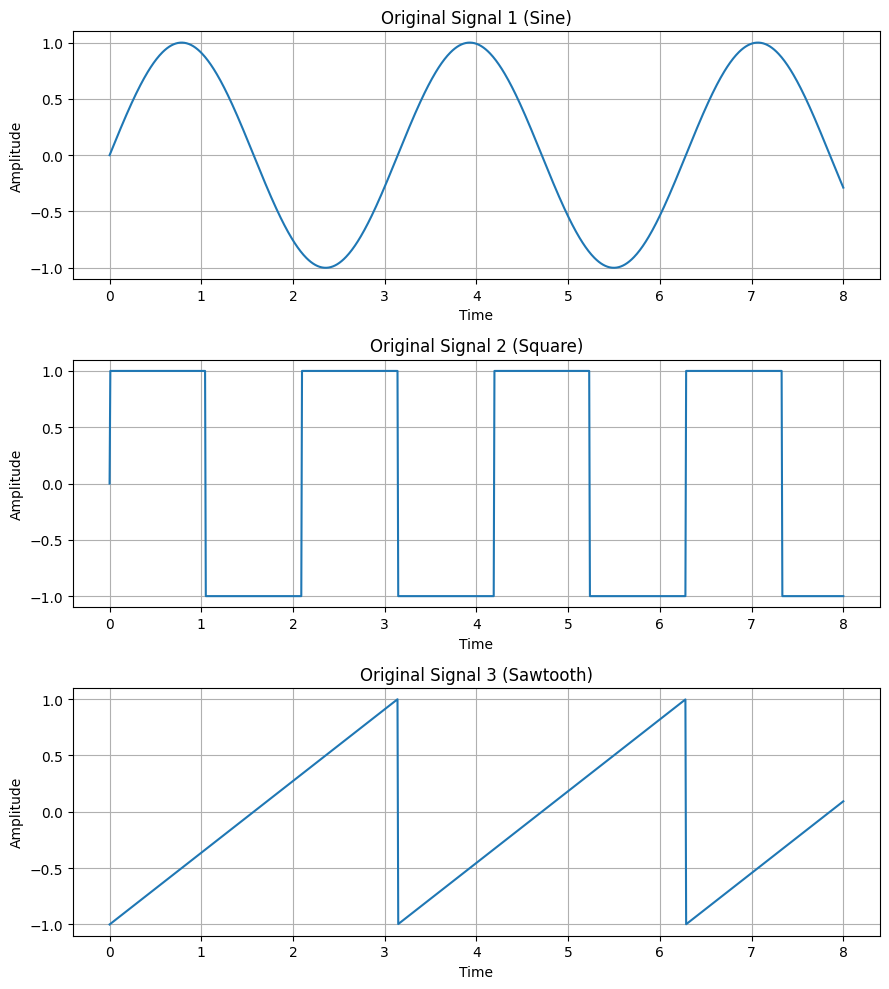

In [7]:
# Step 3: Plot original source signals

# TODO:
# Create a line plot for each source signal
# Add legend, title, labels, and grid
#---------------------------------

plt.figure(figsize=(9, 10))

plt.subplot(3,1,1)
plt.plot(time, s1)
plt.title("Original Signal 1 (Sine)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,2)
plt.plot(time, s2)
plt.title("Original Signal 2 (Square)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,3)
plt.plot(time, s3)
plt.title("Original Signal 3 (Sawtooth)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

In [8]:
# Step 4: Define a mixing matrix and create mixed signals

# TODO:
# A = np.array([
#     [1.0, 1.0, 0.5],
#     [0.5, 2.0, 1.0],
#     [1.5, 1.0, 2.0]
# ])
# X = np.dot(S, A.T)
# print(X.shape)
#---------------------------------------------

A = np.array([
    [1.0, 1.0, 0.5],
    [0.5, 2.0, 1.0],
    [1.5, 1.0, 2.0]
])

X = np.dot(S, A.T)
print(X.shape)

(1000, 3)


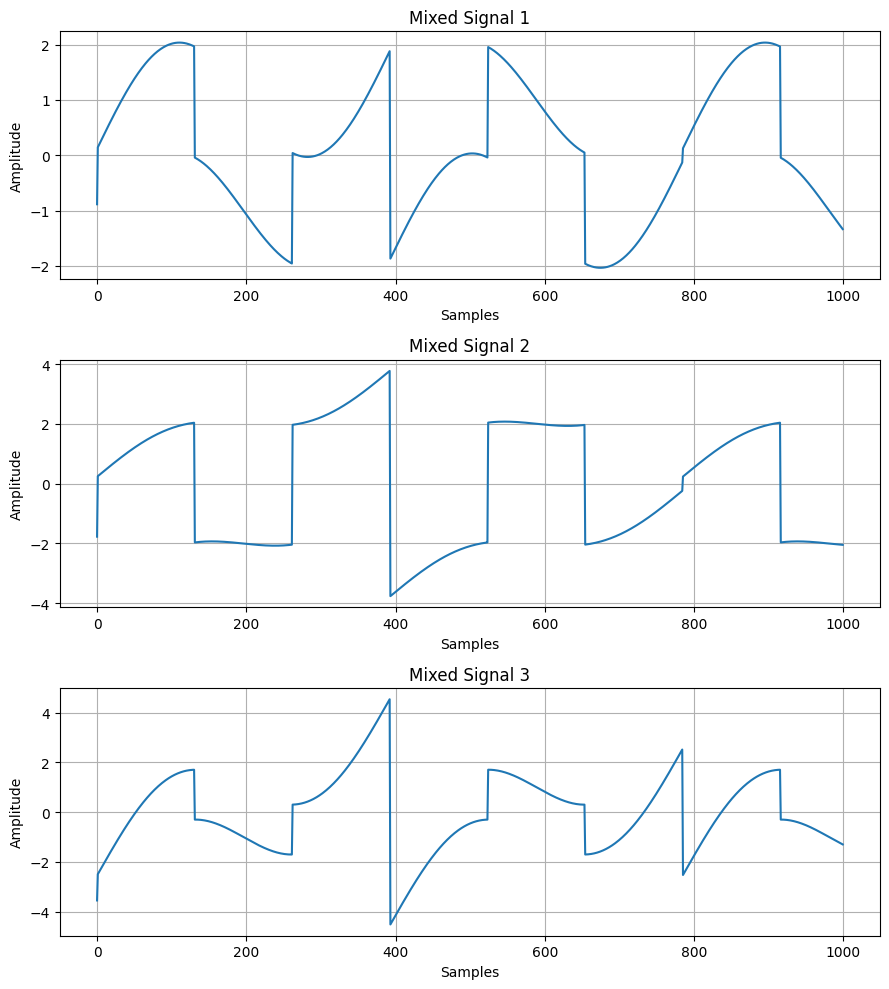

In [9]:
# Step 5: Plot the mixed signals

# TODO:
# Create line plots for the mixed signals
#--------------------------------------------

plt.figure(figsize=(9, 10))

plt.subplot(3,1,1)
plt.plot(X[:,0])
plt.title("Mixed Signal 1")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,2)
plt.plot(X[:,1])
plt.title("Mixed Signal 2")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,3)
plt.plot(X[:,2])
plt.title("Mixed Signal 3")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()


In [10]:
# Step 6: Apply ICA

# TODO:
# ica = FastICA(n_components=3, random_state=42)
# S_est = ...
# A_est = ...
# print(S_est.shape)
# print(A_est.shape)
#--------------------------------------------------

ica = FastICA(n_components=3, random_state=42)
S_est = ica.fit_transform(X)   # Recovered signals
A_est = ica.mixing_
print(S_est.shape)
print(A_est.shape)

(1000, 3)
(3, 3)


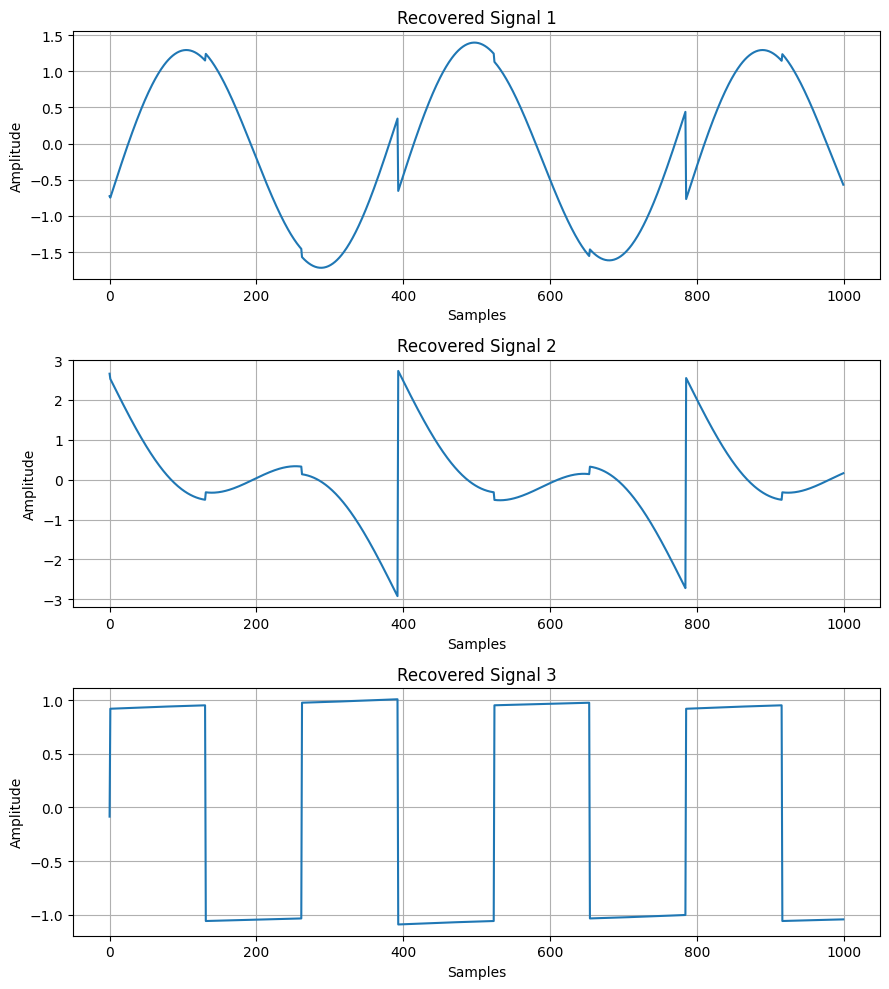

In [11]:
# Step 7: Plot the recovered independent components

# TODO:
# Create line plots for the recovered signals
# Compare visually with the original signals
#----------------------------------------------------

plt.figure(figsize=(9, 10))

plt.subplot(3,1,1)
plt.plot(S_est[:,0])
plt.title("Recovered Signal 1")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,2)
plt.plot(S_est[:,1])
plt.title("Recovered Signal 2")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(3,1,3)
plt.plot(S_est[:,2])
plt.title("Recovered Signal 3")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

plt.tight_layout()
plt.show()

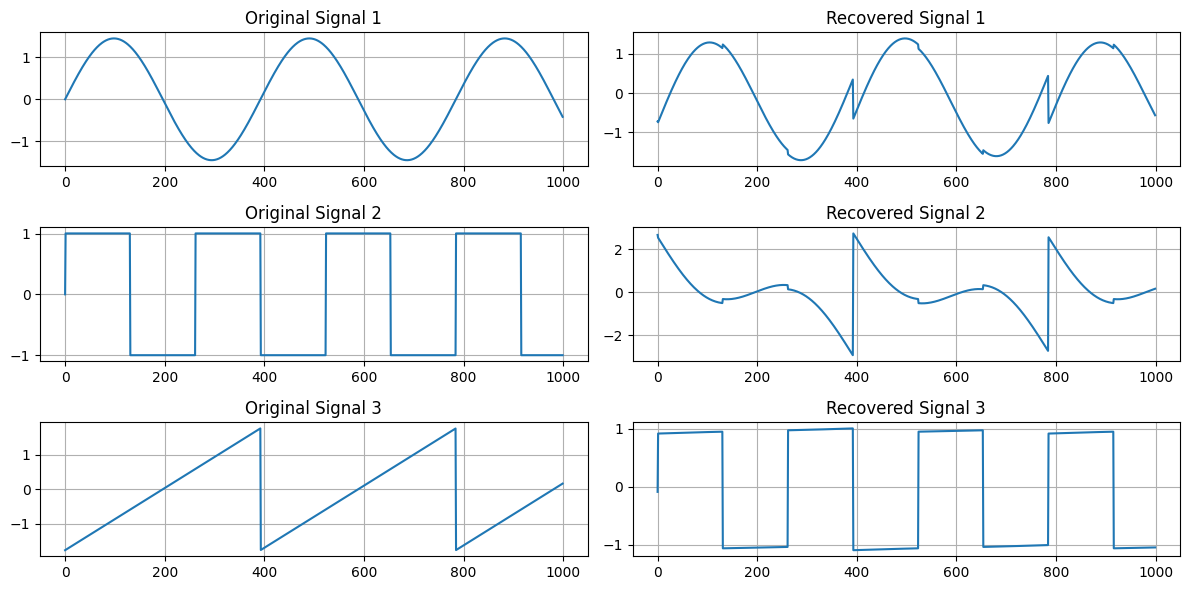

In [12]:
#Comparison plot (Original vs Recovered)
plt.figure(figsize=(12, 6))

for i in range(3):
    plt.subplot(3,2,2*i+1)
    plt.plot(S[:,i])
    plt.title(f"Original Signal {i+1}")
    plt.grid()

    plt.subplot(3,2,2*i+2)
    plt.plot(S_est[:,i])
    plt.title(f"Recovered Signal {i+1}")
    plt.grid()

plt.tight_layout()
plt.show()

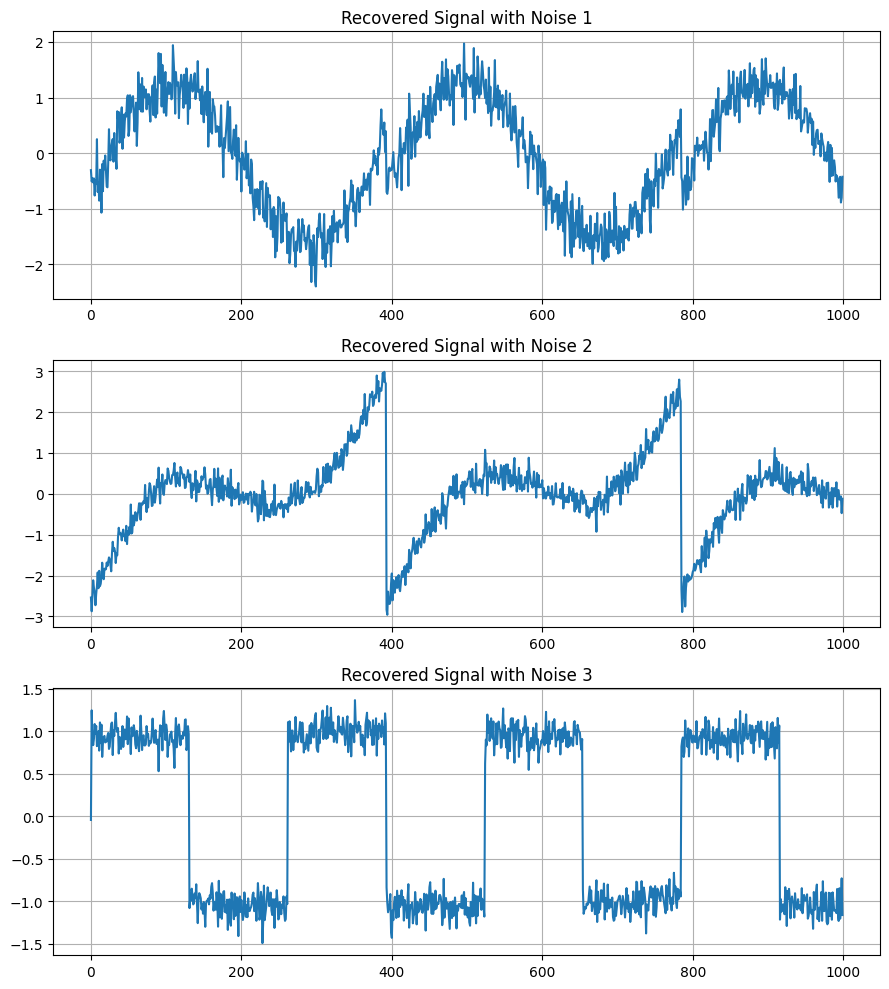

In [13]:
# Optional Challenge
# Add a small amount of Gaussian noise or modify the mixing matrix,
# then repeat the experiment and compare the recovered components.

# TODO:
# noise = ...
# X_noisy = ...
# run ICA again
# compare the result visually
#--------------------------------------------------
noise = 0.2 * np.random.normal(size=X.shape)
X_noisy = X + noise

ica_noisy = FastICA(n_components=3, random_state=42)
S_est_noisy = ica_noisy.fit_transform(X_noisy)

plt.figure(figsize=(9,10))

for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(S_est_noisy[:,i])
    plt.title(f"Recovered Signal with Noise {i+1}")
    plt.grid()

plt.tight_layout()
plt.show()


In [ ]:
# Student observation
#    1. How similar are the recovered signals to the original?
#    Ans: The recovered signals are mostly similar to the original ones in shape. 
#         There can be some small differences in amplitude or scaling, but overall the pattern is almost the same.
    
#    2. Why may ICA return sources in a different order?
#    Ans: ICA can return the signals in a different order because it does not follow any fixed sequence. 
#         It just separates them, so the order may change.
    
#    3. Why can the sign of a component be reversed?
#    Ans: The sign of the signal can be reversed because ICA cannot identify the exact direction. 
#         So sometimes the signal looks flipped, but it still represents the same data.
    
#    4. Why is ICA more suitable than PCA for source separation?
#    Ans: ICA is better for source separation because it focuses on independent signals, while PCA only focuses on variance. 
#         So ICA can separate original sources more effectively.


In [ ]:
# Student Observation
#    1. How similar are the recovered signals to the original?
#    Ans:The recovered signals are mostly similar to the original ones in shape. 
#        There can be some small differences in amplitude or scaling, but overall the pattern is almost the same.
    
#    2. Why may ICA return sources in a different order?
#    Ans:ICA can return the signals in a different order because it doesn’t follow any fixed sequence. 
#        It just separates them, so the order may change.
            
#    3. Why can the sign of a component be reversed?
#    Ans:The sign of the signal can be reversed because ICA cannot identify the exact direction. 
#        So sometimes the signal looks flipped, but it still represents the same data.
            
#    4. Why is ICA more suitable than PCA for source separation?
#    Ans:ICA is better for source separation because it focuses on independent signals, while PCA only focuses on variance. 
#        So ICA can separate original sources more effectively.